 ## CPSC 4970 M1 Homework - Jonathan Braun


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"

housing = pd.read_csv(url)

In [3]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


The column ocean_proximity is textual so it will be removed. Additionally, rows with missing values will be dropped.

In [5]:
housing = housing.drop(columns=["ocean_proximity"])
housing = housing.dropna()

In [6]:
housing.info()

<class 'pandas.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
dtypes: float64(9)
memory usage: 1.6 MB


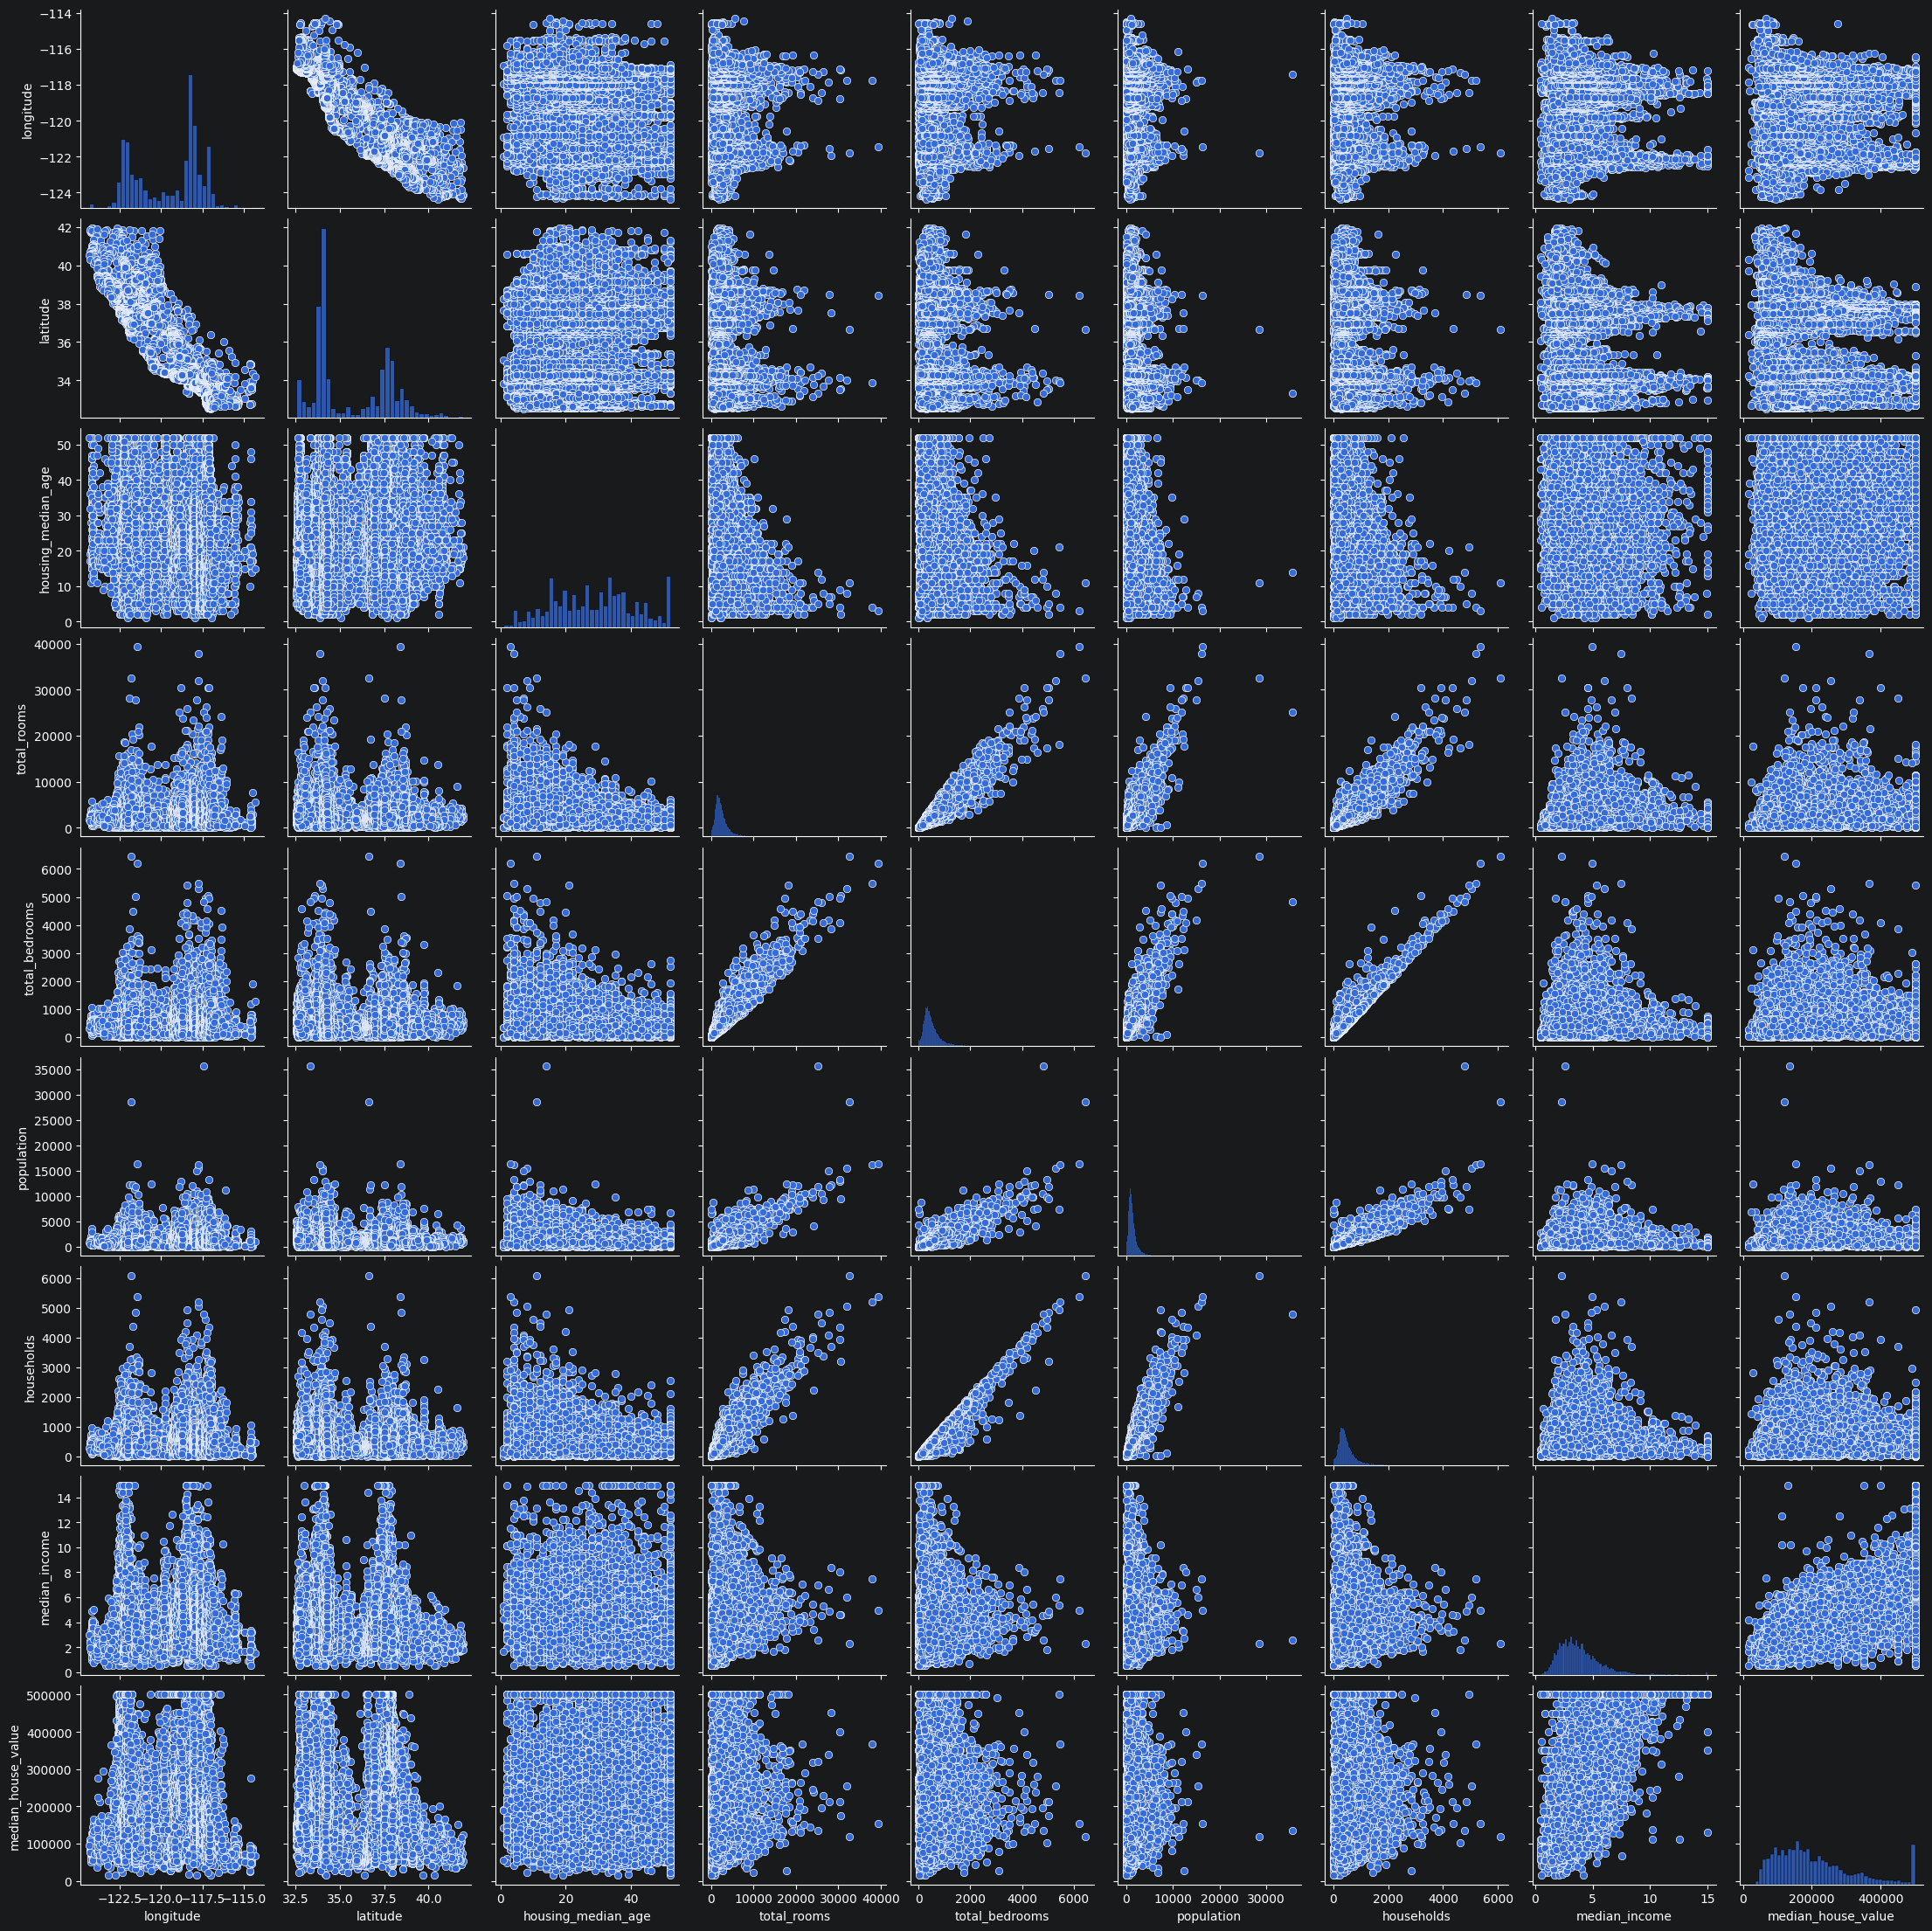

In [7]:
sns.pairplot(housing)
plt.show()

The feature median_income appears to have the strongest linear relationship to the median house value target.

In [8]:
x = housing[["median_income"]]
y = housing["median_house_value"]

In [9]:
print("x type:", type(x))
print("y type:", type(y))

x type: <class 'pandas.DataFrame'>
y type: <class 'pandas.Series'>


In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [11]:
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (15324, 1)
x_test shape: (5109, 1)
y_train shape: (15324,)
y_test shape: (5109,)


In [12]:
print("x_train type:", type(x_train))
print("x_test type:", type(x_test))
print("y_train type:", type(y_train))
print("y_test type:", type(y_test))

x_train type: <class 'pandas.DataFrame'>
x_test type: <class 'pandas.DataFrame'>
y_train type: <class 'pandas.Series'>
y_test type: <class 'pandas.Series'>


## Linear Regression

A linear regression model is created and fit to the training data.

In [13]:
model = LinearRegression()

model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 45651.03110760945
Slope: 41644.560485394904


The intercept represents the predicted median house value when the selected feature is 0. The slope represents how much the predicted median house value changes for a one unit increase in median income.

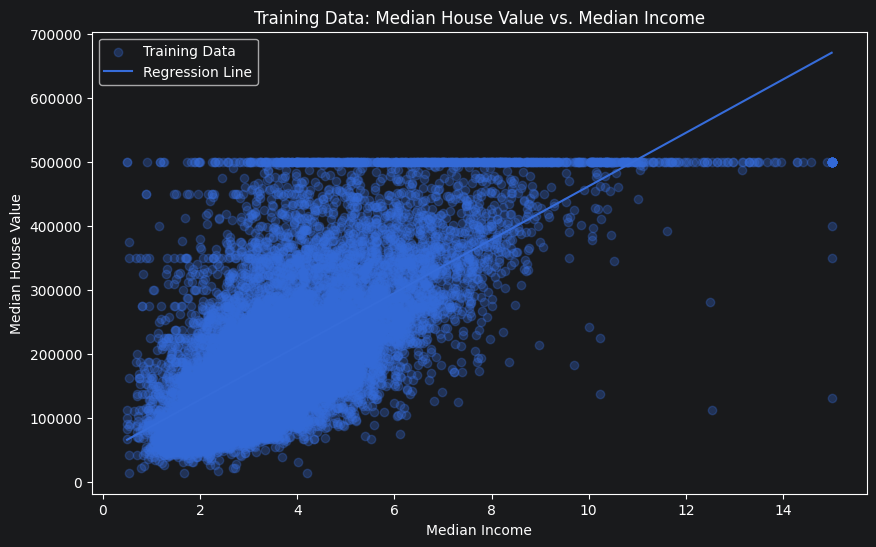

In [15]:
y_train_pred = model.predict(x_train)

x_line = np.linspace(
    x_train["median_income"].min(),
    x_train["median_income"].max(),
    100
)

x_line_df = pd.DataFrame({"median_income": x_line})

y_line = model.predict(x_line_df)

plt.figure(figsize=(10, 6))
plt.scatter(x_train, y_train, alpha=0.3, label="Training Data")
plt.plot(x_line, y_line, label="Regression Line")

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Training Data: Median House Value vs. Median Income")
plt.legend()
plt.show()

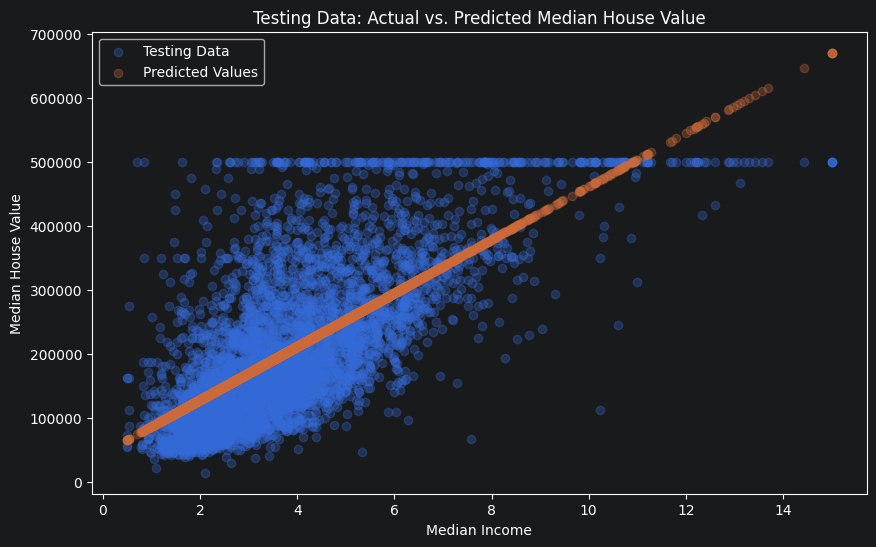

In [16]:
y_test_pred = model.predict(x_test)

plt.figure(figsize=(10, 6))
plt.scatter(x_test, y_test, alpha=0.3, label="Testing Data")
plt.scatter(x_test, y_test_pred, alpha=0.3, label="Predicted Values")

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Testing Data: Actual vs. Predicted Median House Value")
plt.legend()
plt.show()

In [17]:
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print("Training R^2:", train_r2)
print("Testing R^2:", test_r2)
print("Training MSE:", train_mse)
print("Testing MSE:", test_mse)

Training R^2: 0.4721543215143691
Testing R^2: 0.47872609012331746
Training MSE: 6997481718.923447
Testing MSE: 7052223802.224631


In [18]:
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

average_target_value = y.mean()

train_rmse_percentage = (train_rmse / average_target_value) * 100
test_rmse_percentage = (test_rmse / average_target_value) * 100

print("Average median house value:", average_target_value)
print("Training RMSE:", train_rmse)
print("Testing RMSE:", test_rmse)
print("Training RMSE as percentage of average target value:", train_rmse_percentage)
print("Testing RMSE as percentage of average target value:", test_rmse_percentage)

Average median house value: 206864.41315519012
Training RMSE: 83650.951691678
Testing RMSE: 83977.5196241508
Training RMSE as percentage of average target value: 40.43757474560057
Testing RMSE as percentage of average target value: 40.59544043525296


The MSE values are difficult to interpret directly because they are in squared units. To make comparison more meaningful, I used RMSE because it is in the same units as median_house_value. The training and testing RMSE values show the typical prediction error of the model. Comparing RMSE to the average target value shows how large the model's error is relative to the average median house value. Since the RMSE is a fairly large percentage of the average target value, this one feature linear regression model is limited.